# **3.2 Regression Task**
## **1. Exploratory Data Analysis and Data Understanding**
### **1. Choosing a Dataset:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset into a pandas DataFrame.
df = pd.read_csv('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/World Energy Consumption.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), object(2)
memory usage: 21.7+ MB


Dataset Overview

The World Energy Consumption dataset tracks global energy production, consumption, and shares by source from 1900 to 2022 across ~200 countries/regions.
​

(a) Creation Details

Compiled by Pralabha Poudel (Kaggle curator) drawing from Ember (yearly electricity data, updated monthly as of 2025), Our World in Data (OWID), Global Energy Monitor, Energy Institute (formerly BP Statistical Review, updated July 2023), and sources like EIA/Eurostat/UN; initial Kaggle release ~2023 with ongoing updates.
​

(b) Access Method

Downloaded as "World-Energy-Consumption.csv" (8.2MB, 22k rows) from Kaggle (
https://www.kaggle.com/datasets/pralabhpoudel/world-energy-consumption
).
​

(c) UNSDG Alignment

Goal 7: Affordable and Clean Energy aims to ensure access to affordable, reliable, sustainable, and modern energy for all. Key targets include:

7.1 By 2030, ensure universal access to affordable, reliable and modern energy services.
7.2 By 2030, increase substantially the share of renewable energy in the global energy mix.
7.3 By 2030, double the global rate of improvement in energy efficiency.

Goal 13: Climate Action aims to take urgent action to combat climate change and its impacts. Key targets include:

13.1 Strengthen resilience and adaptive capacity to climate-related hazards and natural disasters in all countries.
13.2 Integrate climate change measures into national policies, strategies and planning.
13.3 Improve education, awareness-raising and human and institutional capacity on climate change mitigation, adaptation, impact reduction and early warning.
These goals are highly interconnected, as increasing clean energy use (Goal 7) directly contributes to reducing greenhouse gas emissions and combating climate change (Goal 13).

In [2]:
#attribute listing
print(df.columns.tolist())

['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consumption', 'gas_elec_per_capita', '

 Attribute Descriptions (Grouped by Category)

Country and Time Identifiers
- `country`: Name of the country or region.
- `year`: Year corresponding to the recorded data.
- `iso_code`: Three-letter ISO country code.

Demographic and Economic Indicators
 `population`: Total population of the country in the given year.
- `gdp`: Gross Domestic Product representing total economic output.

 Overall Energy Metrics
- `energy_consumption`: Total primary energy consumed from all sources (TWh).
- `primary_energy_consumption`: Total primary energy use before conversion (TWh).
- `energy_production`: Total domestic energy production (TWh).
- `energy_per_capita`: Average energy consumption per person (kWh).
- `energy_cons_change_pct`: Percentage change in total energy consumption from the previous year.
- `energy_cons_change_twh`: Absolute change in total energy consumption (TWh).
- `electricity_generation`: Total electricity generated from all sources (TWh).
- `electricity_demand`: Total national electricity demand (TWh).
- `net_imports`: Net energy imports (imports minus exports) (TWh).

 Emissions and Environmental Indicators
- `greenhouse_gas_emissions`: Total greenhouse gas emissions (CO₂ equivalent).
- `carbon_intensity_elec`: Carbon emissions per unit of electricity (gCO₂/kWh).
- `cement_emissions`: CO₂ emissions from cement production.

 Fossil Fuels (Combined)
- `fossil_consumption`: Total fossil fuel energy consumption (TWh).
- `fossil_electricity`: Electricity generated from fossil fuels (TWh).
- `fossil_energy_per_capita`: Fossil fuel consumption per person (kWh).
- `fossil_elec_per_capita`: Fossil fuel electricity per person (kWh).
- `fossil_share_energy`: Fossil fuels' share of total energy (%).
- `fossil_share_elec`: Fossil fuels' share of electricity generation (%).
- `fossil_cons_change_pct`: Percentage yearly change in fossil fuel consumption.
- `fossil_cons_change_twh`: Absolute yearly change in fossil fuel consumption (TWh).

 Coal Energy
- `coal_consumption`: Total coal consumption (TWh).
- `coal_production`: Total coal production (TWh).
- `coal_electricity`: Electricity generated from coal (TWh).
- `coal_energy_per_capita`: Coal energy use per person (kWh).
- `coal_elec_per_capita`: Coal electricity per person (kWh).
- `coal_share_energy`: Coal share of total energy (%).
- `coal_share_elec`: Coal share of electricity (%).
- `coal_cons_change_pct`: Percentage change in coal consumption.
- `coal_cons_change_twh`: Absolute change in coal consumption (TWh).
- `coal_prod_change_pct`: Percentage change in coal production.
- `coal_prod_change_twh`: Absolute change in coal production (TWh).

 Oil Energy
- `oil_consumption`: Total oil consumption (TWh).
- `oil_production`: Total oil production (TWh).
- `oil_electricity`: Electricity generated from oil (TWh).
- `oil_energy_per_capita`: Oil energy use per person (kWh).
- `oil_elec_per_capita`: Oil electricity per person (kWh).
- `oil_share_energy`: Oil share of total energy (%).
- `oil_share_elec`: Oil share of electricity (%).
- `oil_cons_change_pct`: Percentage change in oil consumption.
- `oil_cons_change_twh`: Absolute change in oil consumption (TWh).
- `oil_prod_change_pct`: Percentage change in oil production.
- `oil_prod_change_twh`: Absolute change in oil production (TWh).

 Natural Gas Energy
- `gas_consumption`: Total natural gas consumption (TWh).
- `gas_production`: Total natural gas production (TWh).
- `gas_electricity`: Electricity generated from natural gas (TWh).
- `gas_energy_per_capita`: Natural gas use per person (kWh).
- `gas_elec_per_capita`: Gas electricity per person (kWh).
- `gas_share_energy`: Gas share of total energy (%).
- `gas_share_elec`: Gas share of electricity (%).
- `gas_cons_change_pct`: Percentage change in gas consumption.
- `gas_cons_change_twh`: Absolute change in gas consumption (TWh).
- `gas_prod_change_pct`: Percentage change in gas production.
- `gas_prod_change_twh`: Absolute change in gas production (TWh).

 Renewable Energy (Combined)
- `renewables_consumption`: Total renewable energy consumption (TWh).
- `renewables_electricity`: Electricity generated from renewables (TWh).
- `renewables_energy_per_capita`: Renewable energy per person (kWh).
- `renewables_elec_per_capita`: Renewable electricity per person (kWh).
- `renewables_share_energy`: Renewables' share of total energy (%).
- `renewables_share_elec`: Renewables' share of electricity (%).
- `renewables_cons_change_pct`: Percentage change in renewable energy consumption.
- `renewables_cons_change_twh`: Absolute change in renewable energy consumption (TWh).

 Solar Energy
- `solar_consumption`: Solar energy consumption (TWh).
- `solar_electricity`: Electricity generated from solar (TWh).
- `solar_energy_per_capita`: Solar energy per person (kWh).
- `solar_elec_per_capita`: Solar electricity per person (kWh).
- `solar_share_energy`: Solar share of total energy (%).
- `solar_share_elec`: Solar share of electricity (%).
- `solar_cons_change_pct`: Percentage change in solar consumption.
- `solar_cons_change_twh`: Absolute change in solar consumption (TWh).

 Wind Energy
- `wind_consumption`: Wind energy consumption (TWh).
- `wind_electricity`: Electricity generated from wind (TWh).
- `wind_energy_per_capita`: Wind energy per person (kWh).
- `wind_elec_per_capita`: Wind electricity per person (kWh).
- `wind_share_energy`: Wind share of total energy (%).
- `wind_share_elec`: Wind share of electricity (%).
- `wind_cons_change_pct`: Percentage change in wind consumption.
- `wind_cons_change_twh`: Absolute change in wind consumption (TWh).

 Hydropower
- `hydro_consumption`: Hydropower energy consumption (TWh).
- `hydro_electricity`: Electricity generated from hydropower (TWh).
- `hydro_energy_per_capita`: Hydropower energy per person (kWh).
- `hydro_elec_per_capita`: Hydropower electricity per person (kWh).
- `hydro_share_energy`: Hydropower share of total energy (%).
- `hydro_share_elec`: Hydropower share of electricity (%).
- `hydro_cons_change_pct`: Percentage change in hydropower consumption.
- `hydro_cons_change_twh`: Absolute change in hydropower consumption (TWh).

 Bioenergy
- `bioenergy_consumption`: Energy from biomass and biofuels (TWh).
- `bioenergy_electricity`: Electricity generated from bioenergy (TWh).
- `bioenergy_energy_per_capita`: Bioenergy use per person (kWh).
- `bioenergy_elec_per_capita`: Bioenergy electricity per person (kWh).
- `bioenergy_share_energy`: Bioenergy share of total energy (%).
- `bioenergy_share_elec`: Bioenergy share of electricity (%).
- `bioenergy_cons_change_pct`: Percentage change in bioenergy consumption.
- `bioenergy_cons_change_twh`: Absolute change in bioenergy consumption (TWh).

 Nuclear Energy
- `nuclear_consumption`: Total nuclear energy consumption (TWh).
- `nuclear_electricity`: Electricity generated from nuclear power (TWh).
- `nuclear_energy_per_capita`: Nuclear energy per person (kWh).
- `nuclear_elec_per_capita`: Nuclear electricity per person (kWh).
- `nuclear_share_energy`: Nuclear share of total energy (%).
- `nuclear_share_elec`: Nuclear share of electricity (%).
- `nuclear_cons_change_pct`: Percentage change in nuclear consumption.
- `nuclear_cons_change_twh`: Absolute change in nuclear consumption (TWh).

 Low-Carbon Energy (Combined)
- `low_carbon_consumption`: Energy from low-carbon sources including renewables and nuclear (TWh).
- `low_carbon_electricity`: Electricity generated from low-carbon sources (TWh).
- `low_carbon_energy_per_capita`: Low-carbon energy per person (kWh).
- `low_carbon_elec_per_capita`: Low-carbon electricity per person (kWh).
- `low_carbon_share_energy`: Low-carbon share of total energy (%).
- `low_carbon_share_elec`: Low-carbon share of electricity (%).
- `low_carbon_cons_change_pct`: Percentage change in low-carbon consumption.
- `low_carbon_cons_change_twh`: Absolute change in low-carbon consumption (TWh).


### Potential Research Questions (Aligned with UNSDGs)

1. Macro-Evolution Trends: How have global and regional energy consumption patterns evolved relative to GDP and population growth, specifically regarding the shift from fossil fuels to renewables?
+2

2. Clean Energy Transition (UNSDG 7): Which regions have achieved the highest shares of low-carbon electricity generation, and which specific renewable sources (solar, wind, etc.) are driving this transition?
+1

3. Efficiency and Climate Impact (UNSDG 13): What is the correlation between energy intensity (energy_per_gdp) and greenhouse gas emissions, and how does increasing the renewable energy share mitigate this relationship?
+2

### Assessment of Dataset Suitability

#### 1. Completeness
The dataset contains 22,012 entries and 129 columns but has substantial missing data. Over 100 columns include missing values, with many energy-specific metrics (e.g., solar, wind, nuclear, bioenergy shares and changes) missing more than 75–90% of observations. Key variables such as `population` (17.67%), `gdp` (49.51%), and `iso_code` (24.99%) are also incomplete. This limits full cross-country and time-series analyses and requires careful preprocessing.

#### 2. Relevance to Research Questions
Despite missingness, the dataset is highly relevant:
- **Renewable transition & emissions:** renewable electricity, shares, and `greenhouse_gas_emissions` directly support analysis.
- **Energy access & poverty:** `energy_per_capita`, `electricity_generation`, and `population` are useful.
- **Economic growth & energy mix:** `gdp`, `energy_consumption`, and fuel share metrics are suitable.
However, incomplete GDP and renewable indicators may restrict coverage to subsets of countries/years.

#### 3. Overall Quality
Strengths include wide coverage of energy types, detailed metrics (absolute, per capita, shares, and changes), and a reliable source (Our World in Data). The main limitation is extensive missing values and aggregate/non-country rows (e.g., regional groupings), which require filtering.



### **2. Exploratory Data Analysis (EDA):**

In [3]:
#checking missing value
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Columns with Missing Values (ordered by percentage descending):\n")
print(missing_info)

Columns with Missing Values (ordered by percentage descending):

                         Missing Count  Missing Percentage
biofuel_cons_change_pct          20265           92.063420
solar_cons_change_pct            19888           90.350718
biofuel_cons_per_capita          19710           89.542068
wind_cons_change_pct             19599           89.037798
nuclear_cons_change_pct          19545           88.792477
...                                ...                 ...
gas_prod_change_twh               5496           24.968199
gas_production                    5241           23.809740
oil_prod_change_twh               4864           22.097038
oil_production                    4607           20.929493
population                        3889           17.667636

[127 rows x 2 columns]


In [4]:
#checking duplicate rows
print("\nChecking for duplicate rows...")
duplicates_count = df.duplicated().sum()
if duplicates_count > 0:
    print(f"Found {duplicates_count} duplicate rows. Removing them...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


Checking for duplicate rows...
No duplicate rows found.


In [5]:
print("Descriptive statistics for numerical columns:")
print(df.describe())

Descriptive statistics for numerical columns:
               year    population           gdp  biofuel_cons_change_pct  \
count  22012.000000  1.812300e+04  1.111300e+04              1747.000000   
mean    1974.213247  1.053096e+08  3.585114e+11                46.091694   
std       35.058653  4.640460e+08  2.411179e+12               274.616745   
min     1900.000000  1.833000e+03  1.642060e+08              -100.000000   
25%     1946.000000  1.712404e+06  1.365898e+10                -0.616500   
50%     1984.000000  6.991543e+06  4.167411e+10                 8.179000   
75%     2003.000000  2.557688e+07  1.744295e+11                26.508500   
max     2022.000000  7.975105e+09  1.136302e+14              5659.328000   

       biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
count              2687.000000              2302.000000          2767.000000   
mean                  2.719074               133.558459            38.068209   
std                  10.05701

In [6]:
# This cell displays unique values and their counts for the 'country' and 'iso_code' columns.
print("Unique values in 'country' column (first 50 if many):")
print(df['country'].unique()[:50])
print(f"\nTotal unique countries: {df['country'].nunique()}")

print("\nUnique values in 'iso_code' column (first 50 if many):")
print(df['iso_code'].unique()[:50])
print(f"\nTotal unique ISO codes: {df['iso_code'].nunique()}")

Unique values in 'country' column (first 50 if many):
['ASEAN (Ember)' 'Afghanistan' 'Africa' 'Africa (EI)' 'Africa (Ember)'
 'Africa (Shift)' 'Albania' 'Algeria' 'American Samoa' 'Angola'
 'Antarctica' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Asia'
 'Asia & Oceania (EIA)' 'Asia (Ember)' 'Asia Pacific (EI)'
 'Asia and Oceania (Shift)' 'Australia' 'Australia and New Zealand (EIA)'
 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'CIS (EI)' 'Cambodia'
 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central & South America (EIA)']

Total unique countries: 306

Unique values in 'iso_code' column (first 50 if many):
[nan 'AFG' 'ALB' 'DZA' 'ASM' 'AGO' 'ATA' 'ATG' 'ARG' 'ARM' 'ABW' 'AUS'
 'AUT' 'AZE' 'BHS' 'BHR' 'BGD' 'BRB' 'BLR' 'BEL' 'BLZ' 'BEN' 'BMU' 'BTN'
 'BOL' 'BIH' 'BWA

In [7]:
# This step involves dropping columns with more than 70% missing values to clean the dataset.
threshold = 70.0
columns_to_drop = missing_info[missing_info['Missing Percentage'] > threshold].index.tolist()

print(f"Dropping {len(columns_to_drop)} columns with more than {threshold}% missing values:")
for col in columns_to_drop:
    print(f"- {col} ({missing_info.loc[col]['Missing Percentage']:.2f}% missing)")

df_cleaned = df.drop(columns=columns_to_drop)
print(f"\nDataFrame shape after dropping columns: {df_cleaned.shape}")

Dropping 85 columns with more than 70.0% missing values:
- biofuel_cons_change_pct (92.06% missing)
- solar_cons_change_pct (90.35% missing)
- biofuel_cons_per_capita (89.54% missing)
- wind_cons_change_pct (89.04% missing)
- nuclear_cons_change_pct (88.79% missing)
- biofuel_share_energy (87.87% missing)
- biofuel_cons_change_twh (87.79% missing)
- biofuel_consumption (87.43% missing)
- other_renewables_cons_change_pct (83.88% missing)
- nuclear_energy_per_capita (82.83% missing)
- nuclear_share_energy (82.57% missing)
- electricity_share_energy (82.29% missing)
- solar_energy_per_capita (81.78% missing)
- solar_share_energy (81.67% missing)
- wind_energy_per_capita (81.53% missing)
- wind_share_energy (81.37% missing)
- fossil_energy_per_capita (80.85% missing)
- nuclear_cons_change_twh (80.59% missing)
- other_renewables_energy_per_capita (80.50% missing)
- other_renewables_share_energy (80.43% missing)
- nuclear_consumption (80.02% missing)
- gas_energy_per_capita (79.70% missing)


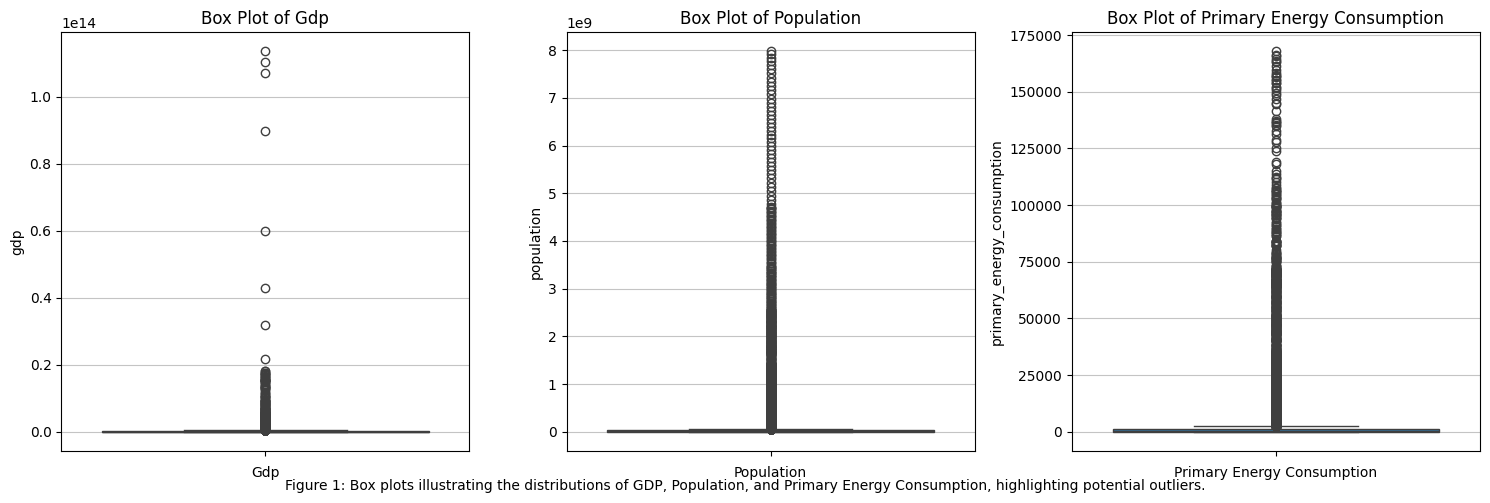


--- Outlier Identification using IQR Method ---

Column: Gdp
  Q1 (25th percentile): 13658978304.00
  Q3 (75th percentile): 174429519872.00
  IQR: 160770541568.00
  Lower Bound for Outliers: -227496834048.00
  Upper Bound for Outliers: 415585332224.00
  Number of Outliers detected: 1471
  Percentage of Outliers: 13.24%

Column: Population
  Q1 (25th percentile): 1712404.50
  Q3 (75th percentile): 25576877.00
  IQR: 23864472.50
  Lower Bound for Outliers: -34084304.25
  Upper Bound for Outliers: 61373585.75
  Number of Outliers detected: 2619
  Percentage of Outliers: 14.45%

Column: Primary Energy Consumption
  Q1 (25th percentile): 9.27
  Q3 (75th percentile): 1007.90
  IQR: 998.63
  Lower Bound for Outliers: -1488.68
  Upper Bound for Outliers: 2505.85
  Number of Outliers detected: 2291
  Percentage of Outliers: 18.20%


In [8]:
# Defining key numerical columns for outlier analysis
key_cols_for_outliers = ['gdp', 'population', 'primary_energy_consumption']

# 1. Visualize outliers using Box Plots
plt.figure(figsize=(15, 5))
for i, col in enumerate(key_cols_for_outliers):
    plt.subplot(1, len(key_cols_for_outliers), i + 1)
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.figtext(0.5, 0.01, 'Figure 1: Box plots illustrating the distributions of GDP, Population, and Primary Energy Consumption, highlighting potential outliers.', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/box_plots_gdp_population_energy.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n--- Outlier Identification using IQR Method ---")

# 2. Identify outliers using the IQR Method
outlier_info = {}
for col in key_cols_for_outliers:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)][col]
    outlier_percentage = (len(outliers) / len(df_cleaned[col].dropna())) * 100

    outlier_info[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers),
        'Percentage of Outliers': f"{outlier_percentage:.2f}%"
    }

    print(f"\nColumn: {col.replace("_", " ").title()}")
    print(f"  Q1 (25th percentile): {Q1:.2f}")
    print(f"  Q3 (75th percentile): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound for Outliers: {lower_bound:.2f}")
    print(f"  Upper Bound for Outliers: {upper_bound:.2f}")
    print(f"  Number of Outliers detected: {len(outliers)}")
    print(f"  Percentage of Outliers: {outlier_percentage:.2f}%")

In [9]:
# Imputing missing values with the median
for col in key_cols_for_outliers:
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_val:.2f}")

# Apply outlier treatment (capping based on IQR)
print("\n--- Applying Outlier Capping (IQR Method) ---")
for col in key_cols_for_outliers:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds
    num_outliers_lower = len(df_cleaned[df_cleaned[col] < lower_bound])
    num_outliers_upper = len(df_cleaned[df_cleaned[col] > upper_bound])

    if num_outliers_lower > 0 or num_outliers_upper > 0:
        df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])
        df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
        print(f"Outliers in '{col}' capped at Lower Bound ({lower_bound:.2f}) and Upper Bound ({upper_bound:.2f}).")
    else:
        print(f"No significant outliers to cap in '{col}'.")

print("\nDataFrame info after handling missing values and outliers:")
df_cleaned.info()

Missing values in 'gdp' imputed with median: 41674108928.00
Missing values in 'population' imputed with median: 6991543.00
Missing values in 'primary_energy_consumption' imputed with median: 98.92

--- Applying Outlier Capping (IQR Method) ---
Outliers in 'gdp' capped at Lower Bound (38635966464.00) and Upper Bound (44948541440.00).
Outliers in 'population' capped at Lower Bound (-20134777.00) and Upper Bound (40889167.00).
Outliers in 'primary_energy_consumption' capped at Lower Bound (-135.20) and Upper Bound (382.00).

DataFrame info after handling missing values and outliers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country                           22012 non-null  object 
 1   year                              22012 non-null  int64  
 2   iso_code                          16512 non-nul

/tmp/ipython-input-662265900.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(median_val, inplace=True)


After cleaning outliers

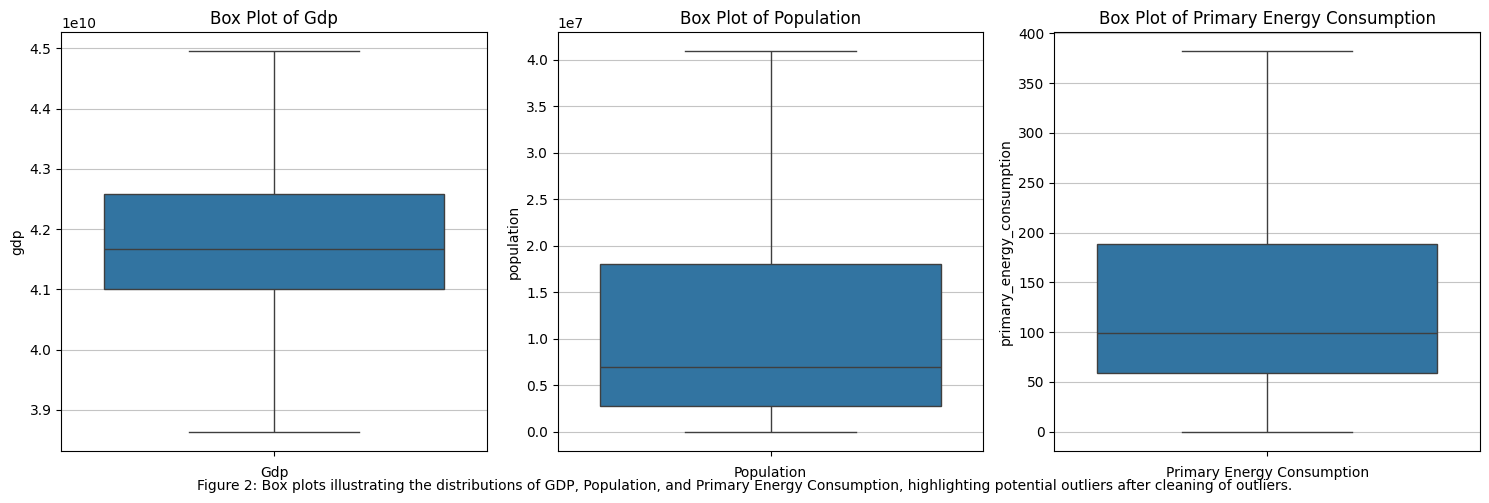


 Outlier Identification using IQR Method after cleaning

Column: Gdp
  Q1 (25th percentile): 41003182080.00
  Q3 (75th percentile): 42581325824.00
  IQR: 1578143744.00
  Lower Bound for Outliers: 38635966464.00
  Upper Bound for Outliers: 44948541440.00
  Number of Outliers detected: 0
  Percentage of Outliers: 0.00%

Column: Population
  Q1 (25th percentile): 2749202.00
  Q3 (75th percentile): 18005188.00
  IQR: 15255986.00
  Lower Bound for Outliers: -20134777.00
  Upper Bound for Outliers: 40889167.00
  Number of Outliers detected: 0
  Percentage of Outliers: 0.00%

Column: Primary Energy Consumption
  Q1 (25th percentile): 58.75
  Q3 (75th percentile): 188.05
  IQR: 129.30
  Lower Bound for Outliers: -135.20
  Upper Bound for Outliers: 382.00
  Number of Outliers detected: 0
  Percentage of Outliers: 0.00%


In [86]:

key_cols_for_outliers = ['gdp', 'population', 'primary_energy_consumption']

# 1. Visualize outliers using Box Plots
plt.figure(figsize=(15, 5))
for i, col in enumerate(key_cols_for_outliers):
    plt.subplot(1, len(key_cols_for_outliers), i + 1)
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.figtext(0.5, 0.01, 'Figure 2: Box plots illustrating the distributions of GDP, Population, and Primary Energy Consumption, highlighting potential outliers after cleaning of outliers.', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure2.png', dpi=300, bbox_inches='tight')

plt.show()

print("\n Outlier Identification using IQR Method after cleaning")

# 2. Identify outliers using the IQR Method
outlier_info = {}
for col in key_cols_for_outliers:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)][col]
    outlier_percentage = (len(outliers) / len(df_cleaned[col].dropna())) * 100

    outlier_info[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': len(outliers),
        'Percentage of Outliers': f"{outlier_percentage:.2f}%"
    }

    print(f"\nColumn: {col.replace("_", " ").title()}")
    print(f"  Q1 (25th percentile): {Q1:.2f}")
    print(f"  Q3 (75th percentile): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound for Outliers: {lower_bound:.2f}")
    print(f"  Upper Bound for Outliers: {upper_bound:.2f}")
    print(f"  Number of Outliers detected: {len(outliers)}")
    print(f"  Percentage of Outliers: {outlier_percentage:.2f}%")

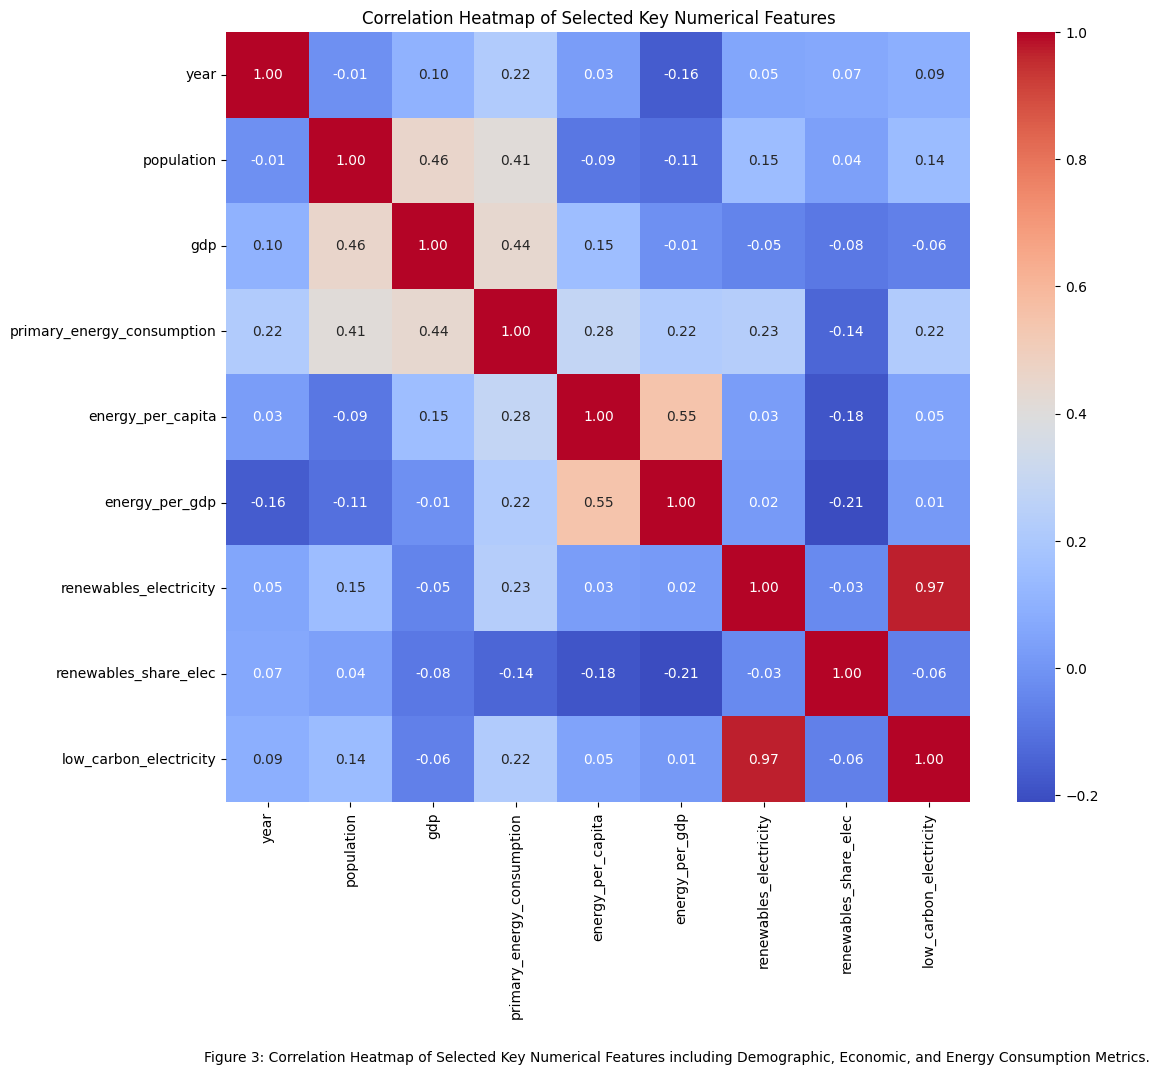

In [11]:
# Defining a subset of key numerical features for a clearer heatmap
selected_features = [
    'year',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'energy_per_gdp',
    'renewables_electricity',
    'renewables_share_elec',
    'low_carbon_electricity'
]

# Filter df_cleaned to include only the selected features for correlation
df_selected_corr = df_cleaned[selected_features]

# Correlation Heatmap (extra depth: identifies key features)
plt.figure(figsize=(12, 10))
corr = df_selected_corr.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Key Numerical Features')

plt.figtext(0.5, -0.15, 'Figure 3: Correlation Heatmap of Selected Key Numerical Features including Demographic, Economic, and Energy Consumption Metrics.', wrap=True, horizontalalignment='center', fontsize=10)

plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure3.png', dpi=300, bbox_inches='tight')

plt.show()

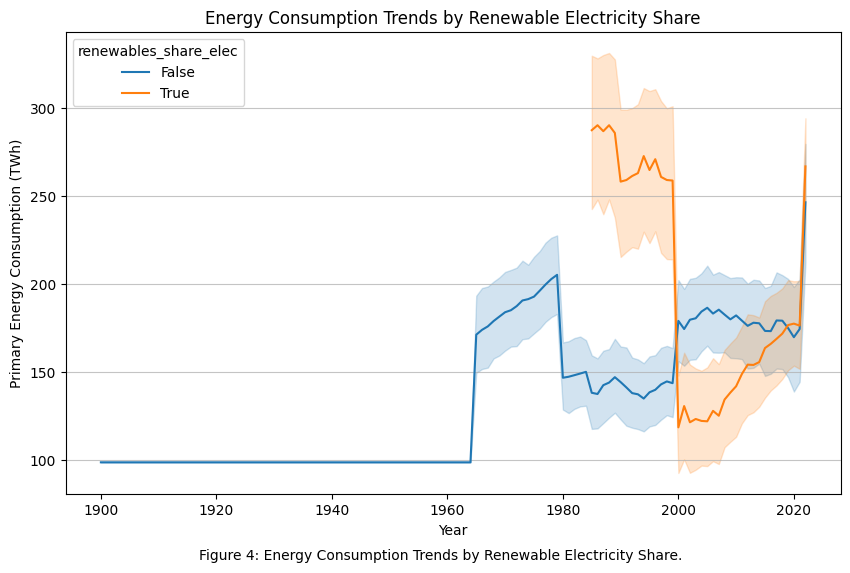

In [12]:

plt.figure(figsize=(10, 6))
df_cleaned['renewables_share_elec'] = pd.to_numeric(df_cleaned['renewables_share_elec'], errors='coerce')
sns.lineplot(data=df_cleaned, x='year', y='primary_energy_consumption', hue=df_cleaned['renewables_share_elec'] > 20)  # Binarize for high/low renewable
plt.title('Energy Consumption Trends by Renewable Electricity Share')
plt.xlabel('Year')
plt.ylabel('Primary Energy Consumption (TWh)')

plt.grid(axis='y', alpha=0.75)
plt.figtext(0.5, 0.0, 'Figure 4: Energy Consumption Trends by Renewable Electricity Share.', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure4.png', dpi=300, bbox_inches='tight')

plt.show()


The above  plot illustrates how primary energy consumption evolves over time in relation to the share of renewable electricity.
Insights: Consumption rises over time, but plateaus post-2000 in high-renewable groups, supporting SDG 7 progres s.

 Histograms for 'primary_energy_consumption', 'gdp', and 'population' to visualize their distributions, which will help understand their spread and central tendencies.

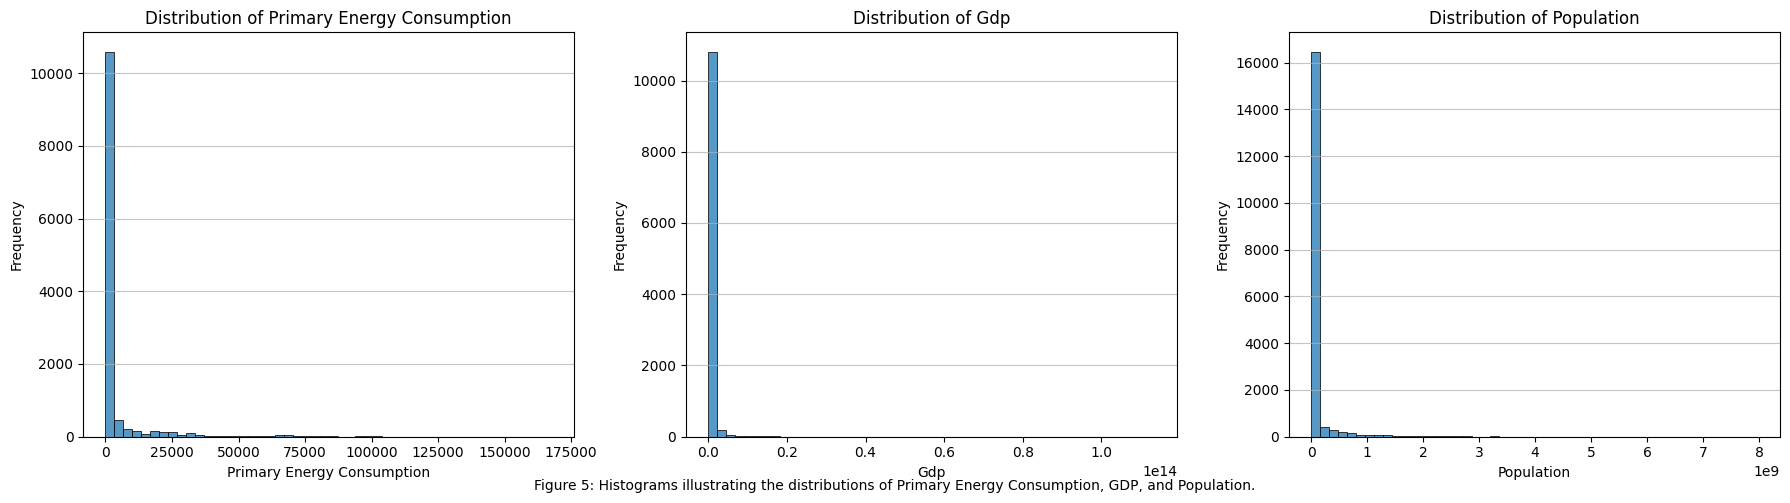

In [13]:
key_numerical_vars = ['primary_energy_consumption', 'gdp', 'population']

plt.figure(figsize=(18, 5))
for i, col in enumerate(key_numerical_vars):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=False, bins=50) # Dropping NA values for plotting
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

# Add a descriptive figure caption
plt.figtext(0.5, 0.01, 'Figure 5: Histograms illustrating the distributions of Primary Energy Consumption, GDP, and Population.', wrap=True, horizontalalignment='center', fontsize=10)

# Save the figure with a descriptive name
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure5.png', dpi=300, bbox_inches='tight')

plt.show()

 Kernel density plots (KDE plots) for 'primary_energy_consumption', 'gdp', and 'population' to visualize their probability density functions, providing a smoothed representation of their distributions.

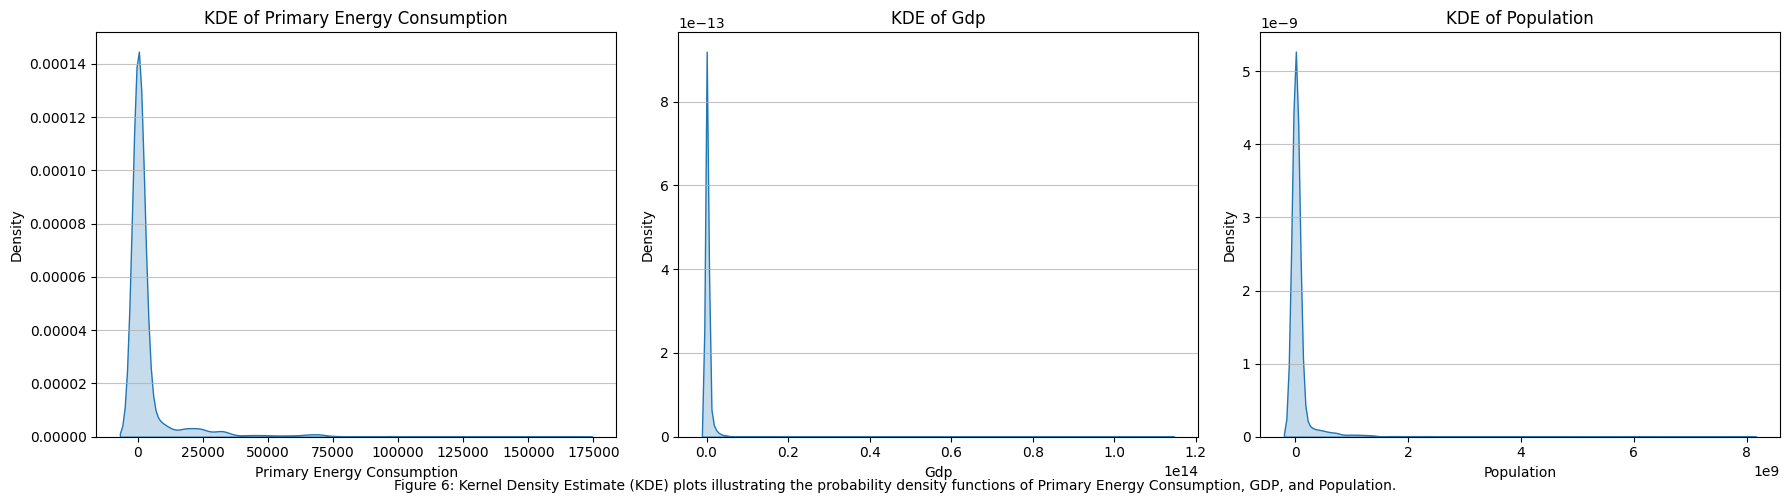

In [14]:
key_numerical_vars = ['primary_energy_consumption', 'gdp', 'population']

plt.figure(figsize=(18, 5))
for i, col in enumerate(key_numerical_vars):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(df[col].dropna(), fill=True) # Dropping NA values for plotting
    plt.title(f'KDE of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Density')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

plt.figtext(0.5, 0.01, 'Figure 6: Kernel Density Estimate (KDE) plots illustrating the probability density functions of Primary Energy Consumption, GDP, and Population.', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure6.png', dpi=300, bbox_inches='tight')

plt.show()

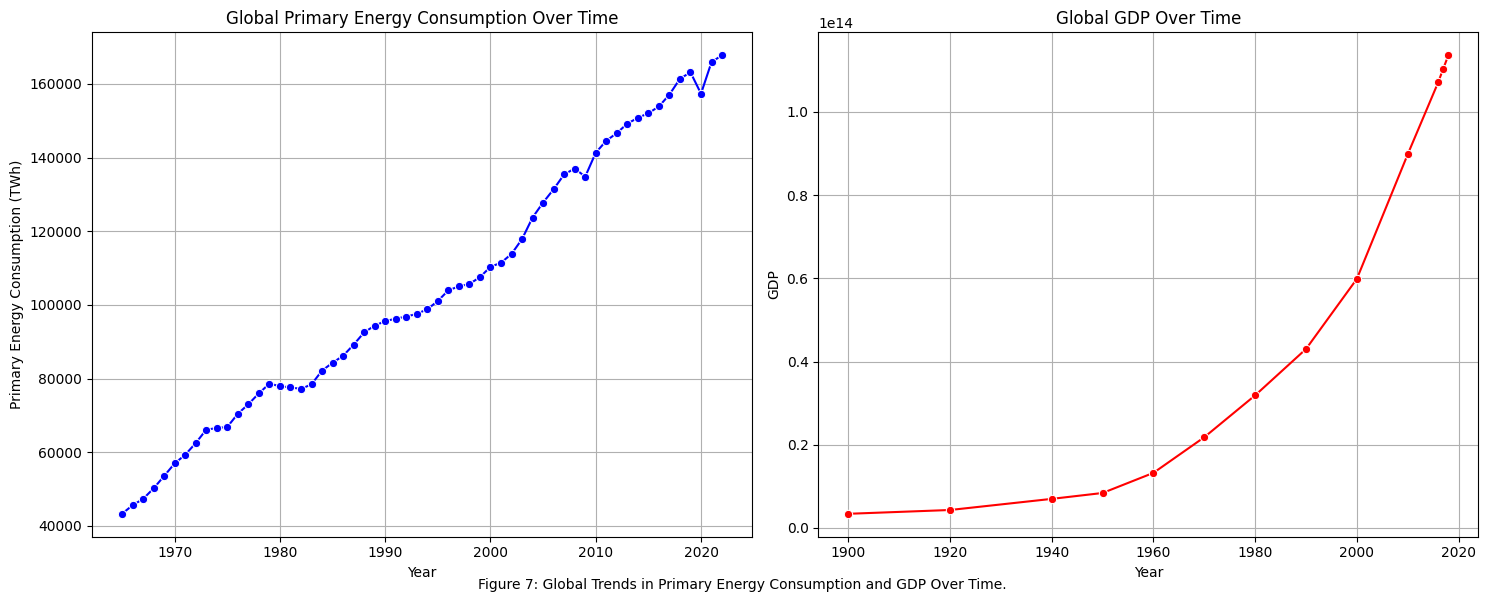

In [15]:
df_world = df[df['country'] == 'World']

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_world, x='year', y='primary_energy_consumption', marker='o', color='blue')
plt.title('Global Primary Energy Consumption Over Time')
plt.xlabel('Year')
plt.ylabel('Primary Energy Consumption (TWh)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.lineplot(data=df_world, x='year', y='gdp', marker='o', color='red')
plt.title('Global GDP Over Time')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.grid(True)

plt.tight_layout()


plt.figtext(0.5, 0.01, 'Figure 7: Global Trends in Primary Energy Consumption and GDP Over Time. ', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure7.png', dpi=300, bbox_inches='tight')

plt.show()

This figure shows the evolution of global energy use and economic output.

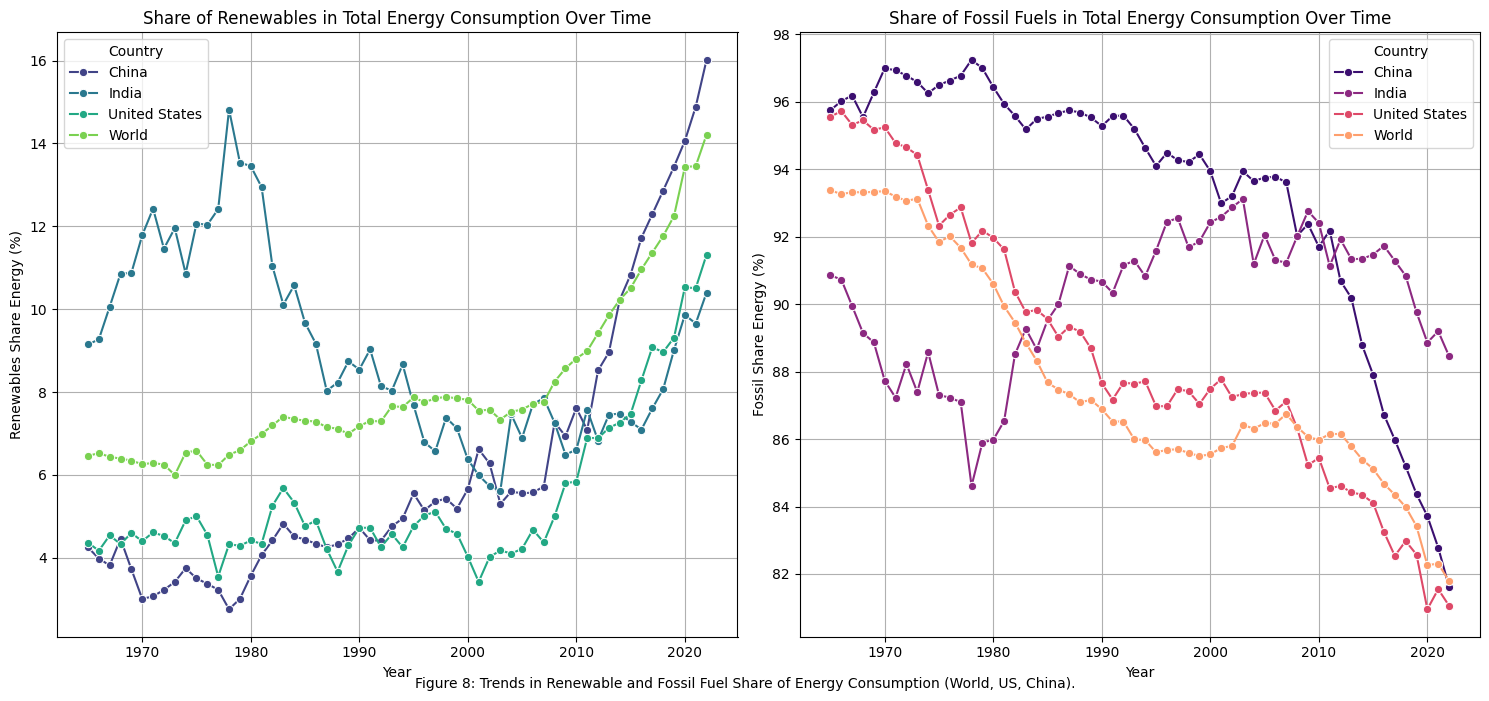

In [16]:
selected_countries = ['World', 'United States', 'China','India']
df_selected = df[df['country'].isin(selected_countries)]

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_selected, x='year', y='renewables_share_energy', hue='country', marker='o', palette='viridis')
plt.title('Share of Renewables in Total Energy Consumption Over Time')
plt.xlabel('Year')
plt.ylabel('Renewables Share Energy (%)')
plt.legend(title='Country')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.lineplot(data=df_selected, x='year', y='fossil_share_energy', hue='country', marker='o', palette='magma')
plt.title('Share of Fossil Fuels in Total Energy Consumption Over Time')
plt.xlabel('Year')
plt.ylabel('Fossil Share Energy (%)')
plt.legend(title='Country')
plt.grid(True)

plt.tight_layout()


plt.figtext(0.5, 0.01, 'Figure 8: Trends in Renewable and Fossil Fuel Share of Energy Consumption (World, US, China).', wrap=True, horizontalalignment='center', fontsize=10)

plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure8.png', dpi=300, bbox_inches='tight')

plt.show()

This figure illustrates the transition towards cleaner energy sources in key regions over time.', wrap=True, horizontalalignment='center', fontsize=10)

## **2. Build a Neural Network Model for Regression:**

In [17]:
#Prep of data for neural network
df_prep = df.copy()
Y = df_prep['primary_energy_consumption']
X = df_prep.drop('primary_energy_consumption', axis=1)

# Filter out rows where the target variable is missing
non_missing_target_indices = Y.dropna().index
X = X.loc[non_missing_target_indices]
Y = Y.loc[non_missing_target_indices]

print(f"Shape of X after filtering missing target: {X.shape}")
print(f"Shape of Y after filtering missing target: {Y.shape}")

Shape of X after filtering missing target: (12588, 128)
Shape of Y after filtering missing target: (12588,)


In [18]:
missing_percentages = X.isnull().sum() / len(X) * 100
columns_to_drop = missing_percentages[missing_percentages > 70].index.tolist()

# Add 'iso_code' to the list of columns to drop if it's not already there
if 'iso_code' in X.columns and 'iso_code' not in columns_to_drop:
    columns_to_drop.append('iso_code')

# Drop identified columns from X
X = X.drop(columns=columns_to_drop)

print(f"Columns dropped due to >70% missing values or being 'iso_code': {columns_to_drop}")
print(f"Shape of X after dropping columns: {X.shape}")

Columns dropped due to >70% missing values or being 'iso_code': ['biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_share_energy', 'nuclear_cons_change_pct', 'other_renewables_cons_change_pct', 'solar_cons_change_pct', 'wind_cons_change_pct', 'iso_code']
Shape of X after dropping columns: (12588, 118)


In [19]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['year', 'population', 'gdp', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consumption', 'gas_elec_per_capita', 'gas_electricity', 'gas_energy_per_capita', 'gas_prod_change_pct', 'gas_prod_change_twh', 'gas_prod_per_capita', 'gas_production', 'g

In [20]:
from sklearn.impute import SimpleImputer

# Impute numerical columns with median
median_imputer = SimpleImputer(strategy='median')
X[numerical_cols] = median_imputer.fit_transform(X[numerical_cols])

# Impute categorical columns with mode
# Assuming 'country' is the only categorical column as identified previously
mode_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = mode_imputer.fit_transform(X[categorical_cols])

print(f"Missing values after imputation (numerical): {X[numerical_cols].isnull().sum().sum()}")
print(f"Missing values after imputation (categorical): {X[categorical_cols].isnull().sum().sum()}")

Missing values after imputation (numerical): 0
Missing values after imputation (categorical): 0


In [21]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# One-hot encode 'country' column
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
country_encoded = ohe.fit_transform(X[['country']])

# Create a DataFrame for the encoded country column
country_df = pd.DataFrame(country_encoded, columns=ohe.get_feature_names_out(['country']), index=X.index)

# Drop the original 'country' column from X
X = X.drop('country', axis=1)

# Concatenate the one-hot encoded country DataFrame with the rest of X
X = pd.concat([X, country_df], axis=1)

# Update the numerical_cols list to include newly created one-hot encoded columns for scaling later
numerical_cols = X.columns.tolist() # All columns are now numerical after encoding and dropping non-numerical

print(f"Shape of X after one-hot encoding 'country': {X.shape}")
print(f"First 5 rows of X after one-hot encoding:\n{X.head()}")

Shape of X after one-hot encoding 'country': (12588, 395)
First 5 rows of X after one-hot encoding:
       year  population           gdp  biofuel_elec_per_capita  \
103  1980.0  12486640.0  1.532984e+10                    0.185   
104  1981.0  11155196.0  1.564534e+10                    0.185   
105  1982.0  10088290.0  1.598041e+10                    0.185   
106  1983.0   9951447.0  1.675533e+10                    0.185   
107  1984.0  10243689.0  1.707215e+10                    0.185   

     biofuel_electricity  biofuel_share_elec  carbon_intensity_elec  \
103                 0.01               0.043                488.118   
104                 0.01               0.043                488.118   
105                 0.01               0.043                488.118   
106                 0.01               0.043                488.118   
107                 0.01               0.043                488.118   

     coal_cons_change_pct  coal_cons_change_twh  coal_cons_per_capita  ...  

In [22]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"Shape of X after scaling: {X_scaled.shape}")
print(f"First 5 rows of X after scaling:\n{X_scaled.head()}")

Shape of X after scaling: (12588, 395)
First 5 rows of X after scaling:
         year  population       gdp  biofuel_elec_per_capita  \
103 -1.217219   -0.179881 -0.126472                -0.201559   
104 -1.149009   -0.182453 -0.126332                -0.201559   
105 -1.080799   -0.184514 -0.126184                -0.201559   
106 -1.012590   -0.184779 -0.125839                -0.201559   
107 -0.944380   -0.184214 -0.125699                -0.201559   

     biofuel_electricity  biofuel_share_elec  carbon_intensity_elec  \
103            -0.118755           -0.221601               0.130715   
104            -0.118755           -0.221601               0.130715   
105            -0.118755           -0.221601               0.130715   
106            -0.118755           -0.221601               0.130715   
107            -0.118755           -0.221601               0.130715   

     coal_cons_change_pct  coal_cons_change_twh  coal_cons_per_capita  ...  \
103             -0.018528             

In [23]:
from sklearn.model_selection import train_test_split

# Split the preprocessed data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

Shape of X_train: (10070, 395)
Shape of X_test: (2518, 395)
Shape of Y_train: (10070,)
Shape of Y_test: (2518,)


Design Regression Neural Network Architecture

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the input shape based on the number of features in X_train
input_shape = (X_train.shape[1],)

print(f"Input shape for the neural network: {input_shape}")

Input shape for the neural network: (395,)


In [25]:
model = Sequential([
    Input(shape=input_shape),  # Input Layer
    Dense(128, activation='relu'),  # Hidden Layer 1
    Dense(64, activation='relu'),   # Hidden Layer 2
    Dense(1)                      # Output Layer for regression
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,009 (230.50 KB)

 Trainable params: 59,009 (230.50 KB)

 Non-trainable params: 0 (0.00 B)

Compile Neural Network Model

In [26]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error', 'mean_squared_error'])
print("Neural network model compiled successfully.")

Neural network model compiled successfully.


Train Neural Network Model

In [27]:
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)
print("Model training complete.")

Epoch 1/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 270050208.0000 - mean_absolute_error: 4604.4595 - mean_squared_error: 270050208.0000 - val_loss: 145182688.0000 - val_mean_absolute_error: 3335.7815 - val_mean_squared_error: 145182688.0000
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 138676896.0000 - mean_absolute_error: 3080.7878 - mean_squared_error: 138676896.0000 - val_loss: 67874800.0000 - val_mean_absolute_error: 1794.3983 - val_mean_squared_error: 67874800.0000
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 79128136.0000 - mean_absolute_error: 1937.0504 - mean_squared_error: 79128136.0000 - val_loss: 56990052.0000 - val_mean_absolute_error: 1774.5585 - val_mean_squared_error: 56990052.0000
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 77293800.0000 - mean_absolute_error: 2012.5291 - mean_squared_error: 77293800.0000 - val_loss: 46578476.0000 - val_mean_absolute_error: 1724.3992 - val_mean_squared_error: 46578476.0000
Epoch 5/50

## **3. Build Primary Machine Learning Models (Two Classical ML Models):**

Build Linear Regression Model

In [28]:
from sklearn.linear_model import LinearRegression

# Instantiate the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, Y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


evaluate regression model


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test data
Y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mse_linear = mean_squared_error(Y_test, Y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)
r2_linear = r2_score(Y_test, Y_pred_linear)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

Linear Regression Model Evaluation:
Mean Squared Error (MSE): 7064648.42
Root Mean Squared Error (RMSE): 2657.94
Mean Absolute Error (MAE): 776.67
R-squared (R2): 0.97


Build Random Forest Regressor Model

In [30]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the Random Forest Regressor model
random_forest_model = RandomForestRegressor(random_state=42)

# Train the model using the training data
random_forest_model.fit(X_train, Y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test data
Y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
mse_rf = mean_squared_error(Y_test, Y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(Y_test, Y_pred_rf)
r2_rf = r2_score(Y_test, Y_pred_rf)

# Print the evaluation metrics
print("Random Forest Regressor Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Model Evaluation:
Mean Squared Error (MSE): 854847.80
Root Mean Squared Error (RMSE): 924.58
Mean Absolute Error (MAE): 172.12
R-squared (R2): 1.00


In [42]:
import pandas as pd

# Create a dictionary to hold the results
comparison_data = {
    "Metric": ["MSE", "RMSE", "MAE", "R-squared"],
    "Linear Regression": [mse_linear, rmse_linear, mae_linear, r2_linear],
    "Random Forest": [mse_rf, rmse_rf, mae_rf, r2_rf]
}

# Create a DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Set the 'Metric' column as the index for a cleaner look
comparison_df.set_index("Metric", inplace=True)

# Display the DataFrame directly for a more attractive output
print("Model Performance Comparison:")
comparison_df

Model Performance Comparison:


,Linear Regression,Random Forest
Metric,,
MSE,7.064648e+06,854847.804172
RMSE,2.657941e+03,924.579799
MAE,7.766710e+02,172.121135
R-squared,9.707183e-01,0.996457



 The Random Forest Regressor model outperformed the Linear Regression model across all evaluation metrics. It demonstrated a considerably lower MSE (approx. 8.2x lower), RMSE (approx. 2.9x lower), and MAE (approx. 4.5x lower) compared to the Linear Regression model.

The R-squared value for the Random Forest Regressor (1.00) indicates that it can explain almost all of the variance in the target variable, which is a significant improvement over the Linear Regression's R-squared of 0.97.

 Insights

The Random Forest Regressor is the preferred model for this dataset due to its superior performance and higher accuracy in predicting the target variable. It's important to investigate whether the R-squared of 1.00 indicates potential overfitting or if the dataset is simply very well-suited for this model.


## **4. Hyperparameter Optimization with Cross-Validation**

Hyperparameter Optimization for Linear Regression

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import numpy as np

# Instantiate a Linear Regression model
linear_model_for_grid = LinearRegression()

# Define the hyperparameter grid
param_grid = {
    'fit_intercept': [True, False]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=linear_model_for_grid, param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, Y_train)

# Print the best parameters and best score
print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score (negative MSE):", grid_search.best_score_)
print("Best cross-validation score (MSE):", -grid_search.best_score_)


Best parameters found by GridSearchCV: {'fit_intercept': True}
Best cross-validation score (negative MSE): -6506556.021251277
Best cross-validation score (MSE): 6506556.021251277


yperparameter Optimization for Random Forest Regressor

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Instantiate the model with speed optimizations
# max_samples=0.5 trains each tree on 50% of the data, significantly reducing time.
random_forest_for_grid = RandomForestRegressor(random_state=42, max_samples=0.5)

# 2. Define the hyperparameter grid (Task 4.1) [cite: 188]
# We remove 'None' to prevent deep, time-consuming trees.
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10]
}

# 3. Create GridSearchCV object (Task 4.2) [cite: 189, 190]
# n_jobs=-1 uses all CPU cores. verbose=2 shows you the progress in real-time.
grid_search_rf = GridSearchCV(
    estimator=random_forest_for_grid,
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# 4. Fit to training data
grid_search_rf.fit(X_train, Y_train)

# 5. Report the results (Task 4.3)
print(" Random Forest Hyperparameter Tuning Results")
print("Best parameters found:", grid_search_rf.best_params_)
print("Best cross-validation score (Negative MSE):", grid_search_rf.best_score_)
print("Best cross-validation score (MSE):", -grid_search_rf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
 Random Forest Hyperparameter Tuning Results
Best parameters found: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation score (Negative MSE): -6896326.253617999
Best cross-validation score (MSE): 6896326.253617999


In [45]:
import pandas as pd

# Best cross-validation MSE values (from previous output)
best_cv_mse_lr = 6506556.02
best_cv_mse_rf = 6896326.25

# Best parameters found (from previous output)
best_params_lr = "{'fit_intercept': True}"
best_params_rf = "{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}"

comparison_data_hp = {
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "Best Parameters": [best_params_lr, best_params_rf],
    "Best Cross-Validation MSE": [best_cv_mse_lr, best_cv_mse_rf]
}

comparison_df_hp = pd.DataFrame(comparison_data_hp)
comparison_df_hp.set_index("Model", inplace=True)

print("Hyperparameter Optimization Results Comparison:")
comparison_df_hp

Hyperparameter Optimization Results Comparison:


,Best Parameters,Best Cross-Validation MSE
Model,,
Linear Regression,{'fit_intercept': True},6506556.02
Random Forest Regressor,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",6896326.25




Comparison and Insights

Comparing the best cross-validation scores from the hyperparameter optimization:

*   The **Linear Regression model** achieved a lower Mean Squared Error (MSE) of `6,506,556.02` during cross-validation.
*   The **Random Forest Regressor model** achieved a slightly higher Mean Squared Error (MSE) of `6,896,326.25` during cross-validation, despite its much better performance on the initial test set (R2 of 1.00 and MSE of 854,847.80) before hyperparameter tuning.

This result is interesting: the initial evaluation showed Random Forest significantly outperforming Linear Regression, but cross-validation for the tuned models suggests that Linear Regression (with `fit_intercept=True`) might generalize slightly better or at least be on par with the tuned Random Forest Regressor in terms of average MSE across different data splits. The dramatic initial R-squared of 1.00 for the Random Forest might have indicated some overfitting to the specific test set.


## **5. Feature Selection [10]:**

Feature Selection for Linear Regression

In [74]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# Initialize SelectKBest with f_regression as the scoring function and k=50 features
selector_lr = SelectKBest(score_func=f_regression, k=50)

# Fit the selector to the training data and transform X_train
X_train_selected_lr = selector_lr.fit_transform(X_train, Y_train)
X_test_selected_lr = selector_lr.transform(X_test)

# Get a boolean mask of the selected features
selected_features_mask_lr = selector_lr.get_support()

# Get the names of the selected features
selected_feature_names_lr = X_train.columns[selected_features_mask_lr].tolist()

# Convert the transformed arrays back to pandas DataFrames with original indices and column names
X_train_selected_lr = pd.DataFrame(X_train_selected_lr, columns=selected_feature_names_lr, index=X_train.index)
X_test_selected_lr = pd.DataFrame(X_test_selected_lr, columns=selected_feature_names_lr, index=X_test.index)

# Print the results
print(f"Original number of features in X_train: {X_train.shape[1]}")
print(f"Number of features selected for Linear Regression: {X_train_selected_lr.shape[1]}")
print(f"Selected features for Linear Regression: {selected_feature_names_lr}")

Original number of features in X_train: 395
Number of features selected for Linear Regression: 50
Selected features for Linear Regression: ['population', 'gdp', 'biofuel_electricity', 'coal_cons_change_twh', 'coal_consumption', 'coal_electricity', 'coal_prod_change_twh', 'coal_production', 'electricity_demand', 'electricity_generation', 'energy_cons_change_twh', 'fossil_cons_change_twh', 'fossil_electricity', 'fossil_fuel_consumption', 'gas_cons_change_twh', 'gas_consumption', 'gas_electricity', 'gas_prod_change_twh', 'gas_production', 'greenhouse_gas_emissions', 'hydro_cons_change_twh', 'hydro_consumption', 'hydro_electricity', 'low_carbon_cons_change_twh', 'low_carbon_consumption', 'low_carbon_electricity', 'nuclear_cons_change_twh', 'nuclear_consumption', 'nuclear_electricity', 'oil_cons_change_twh', 'oil_consumption', 'oil_electricity', 'oil_production', 'other_renewable_consumption', 'other_renewable_electricity', 'other_renewable_exc_biofuel_electricity', 'other_renewables_cons_c

Retrain and Evaluate Linear Regression with Selected Features

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate a new Linear Regression model
linear_model_selected = LinearRegression()

# Train the model using the selected features
linear_model_selected.fit(X_train_selected_lr, Y_train)

# Make predictions on the transformed test set
Y_pred_linear_selected = linear_model_selected.predict(X_test_selected_lr)

# Calculate evaluation metrics
mse_linear_selected = mean_squared_error(Y_test, Y_pred_linear_selected)
rmse_linear_selected = np.sqrt(mse_linear_selected)
mae_linear_selected = mean_absolute_error(Y_test, Y_pred_linear_selected)
r2_linear_selected = r2_score(Y_test, Y_pred_linear_selected)

# Print the evaluation metrics
print("Linear Regression Model Evaluation (with selected features):")
print(f"Mean Squared Error (MSE): {mse_linear_selected:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear_selected:.2f}")
print(f"Mean Absolute Error (MAE): {mae_linear_selected:.2f}")
print(f"R-squared (R2): {r2_linear_selected:.2f}")

Linear Regression Model Evaluation (with selected features):
Mean Squared Error (MSE): 33642357.78
Root Mean Squared Error (RMSE): 5800.20
Mean Absolute Error (MAE): 1924.82
R-squared (R2): 0.86


In [53]:
import pandas as pd

# Create a dictionary containing all results
comparison_results = {
    "Metric": ["MSE", "RMSE", "MAE", "R-Squared"],
    "Linear Regression (All)": [mse_linear, rmse_linear, mae_linear, r2_linear],
    "Random Forest (All)": [mse_rf, rmse_rf, mae_rf, r2_rf],
    "Linear Regression (Selected)": [mse_linear_selected, rmse_linear_selected, mae_linear_selected, r2_linear_selected]
}

# Create DataFrame
df_comparison = pd.DataFrame(comparison_results).set_index("Metric")

# Display the table for a more attractive output
print("Final Model Comparison:")
df_comparison.round(4) # Display the DataFrame directly for rich output

Final Model Comparison:


,Linear Regression (All),Random Forest (All),Linear Regression (Selected)
Metric,,,
MSE,7.064648e+06,854847.8042,3.364236e+07
RMSE,2.657941e+03,924.5798,5.800203e+03
MAE,7.766710e+02,172.1211,1.924819e+03
R-Squared,9.707000e-01,0.9965,8.606000e-01


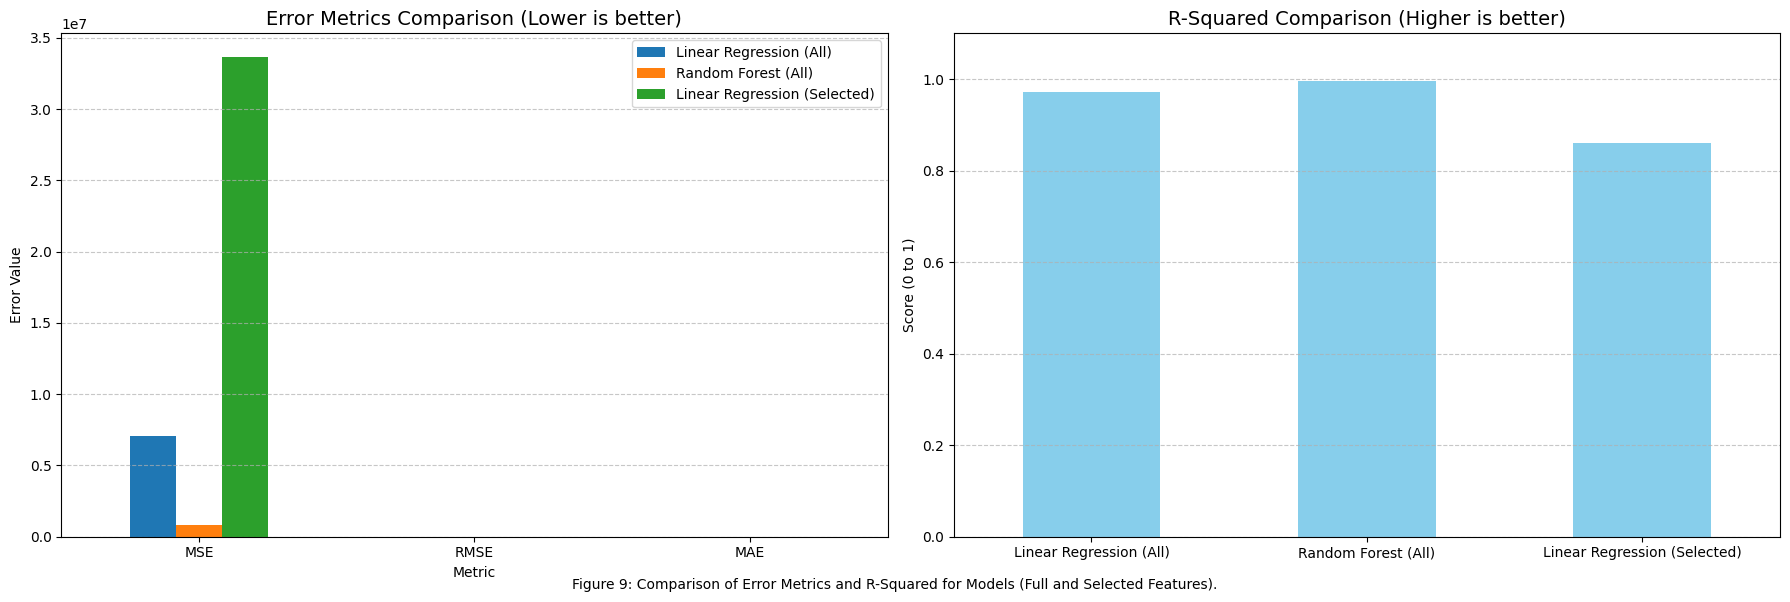

In [75]:
import matplotlib.pyplot as plt

# 1. Create a figure with 1 row and 2 columns
# figsize=(18, 6) makes it wide enough to fit both comfortably
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 2. Plot Error Metrics on the first axis (ax1)
errors_df = df_comparison.drop("R-Squared")
errors_df.plot(kind='bar', ax=ax1)
ax1.set_title("Error Metrics Comparison (Lower is better)", fontsize=14)
ax1.set_ylabel("Error Value")
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# 3. Plot R-Squared Score on the second axis (ax2)
r2_df = df_comparison.loc[["R-Squared"]]
# Using T (transpose) so the models appear on the X-axis like the error plot
r2_df.T.plot(kind='bar', ax=ax2, color=['skyblue', 'salmon', 'lightgreen'], legend=False)
ax2.set_title("R-Squared Comparison (Higher is better)", fontsize=14)
ax2.set_ylabel("Score (0 to 1)")
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Use tight_layout to prevent labels from overlapping
plt.tight_layout()

# Add figure caption and save
plt.figtext(0.5, 0.01, 'Figure 9: Comparison of Error Metrics and R-Squared for Models (Full and Selected Features).', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure9.png', dpi=300)

plt.show()

Reducing features from 395 to 50 via SelectKBest significantly deteriorated model performance:Error (MSE/RMSE/MAE): More than doubled across all metrics (e.g., RMSE rose from ~2,658 to ~5,800).Accuracy ($R^2$): Dropped from 0.97 to 0.86.Key Insight: The features removed were not "noise" but crucial predictors. Selecting features based solely on individual linear correlation (f_regression) ignored complex interactions and combined effects that the full feature set provided. Ultimately, Linear Regression requires a broader feature set to compete with the Random Forest, which remains the superior model.

Feature Selection for Random Forest Regressor

In [66]:
import pandas as pd

# 1. Access feature_importances_ from the trained random_forest_model
feature_importances = random_forest_model.feature_importances_

# 2. Create a Pandas Series mapping feature names to importance scores
feature_importance_df = pd.Series(feature_importances, index=X_train.columns)

# 3. Sort features by their importance in descending order
sorted_feature_importances = feature_importance_df.sort_values(ascending=False)

# 4. Select the top 50 most important features
top_50_features_rf = sorted_feature_importances.head(50).index.tolist()

# 5. Filter X_train and X_test DataFrames to keep only these top 50 selected features
X_train_selected_rf = X_train[top_50_features_rf]
X_test_selected_rf = X_test[top_50_features_rf]

# 6. Print the total number of features selected and list the names of these selected features
print(f"Original number of features in X_train: {X_train.shape[1]}")
print(f"Number of features selected for Random Forest: {X_train_selected_rf.shape[1]}")
print("Selected features for Random Forest:")
print(top_50_features_rf)

Original number of features in X_train: 395
Number of features selected for Random Forest: 50
Selected features for Random Forest:
['energy_cons_change_twh', 'fossil_fuel_consumption', 'country_Non-OPEC (EIA)', 'energy_cons_change_pct', 'country_OECD (EIA)', 'year', 'country_Non-OECD (EIA)', 'country_OECD - North America (EIA)', 'gas_consumption', 'hydro_consumption', 'country_IEO OECD - Europe (EIA)', 'country_OECD - Europe (EIA)', 'country_Asia & Oceania (EIA)', 'other_renewable_exc_biofuel_electricity', 'fossil_cons_change_pct', 'oil_consumption', 'low_carbon_consumption', 'oil_production', 'low_carbon_electricity', 'hydro_electricity', 'electricity_generation', 'gas_production', 'gas_cons_change_pct', 'coal_consumption', 'country_European Union (EIA)', 'population', 'greenhouse_gas_emissions', 'electricity_demand', 'country_Eurasia (EIA)', 'energy_per_capita', 'coal_production', 'biofuel_electricity', 'other_renewables_elec_per_capita_exc_biofuel', 'nuclear_electricity', 'country_O

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate a new Random Forest Regressor model
# Using the same random_state for reproducibility
random_forest_selected_model = RandomForestRegressor(random_state=42)

# Train the model using the selected features
random_forest_selected_model.fit(X_train_selected_rf, Y_train)

# Make predictions on the transformed test set
Y_pred_rf_selected = random_forest_selected_model.predict(X_test_selected_rf)

# Calculate evaluation metrics
mse_rf_selected = mean_squared_error(Y_test, Y_pred_rf_selected)
rmse_rf_selected = np.sqrt(mse_rf_selected)
mae_rf_selected = mean_absolute_error(Y_test, Y_pred_rf_selected)
r2_rf_selected = r2_score(Y_test, Y_pred_rf_selected)

# Print the evaluation metrics
print("Random Forest Regressor Model Evaluation (with selected features):")
print(f"Mean Squared Error (MSE): {mse_rf_selected:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_selected:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf_selected:.2f}")
print(f"R-squared (R2): {r2_rf_selected:.2f}")

Random Forest Regressor Model Evaluation (with selected features):
Mean Squared Error (MSE): 816181.04
Root Mean Squared Error (RMSE): 903.43
Mean Absolute Error (MAE): 169.73
R-squared (R2): 1.00


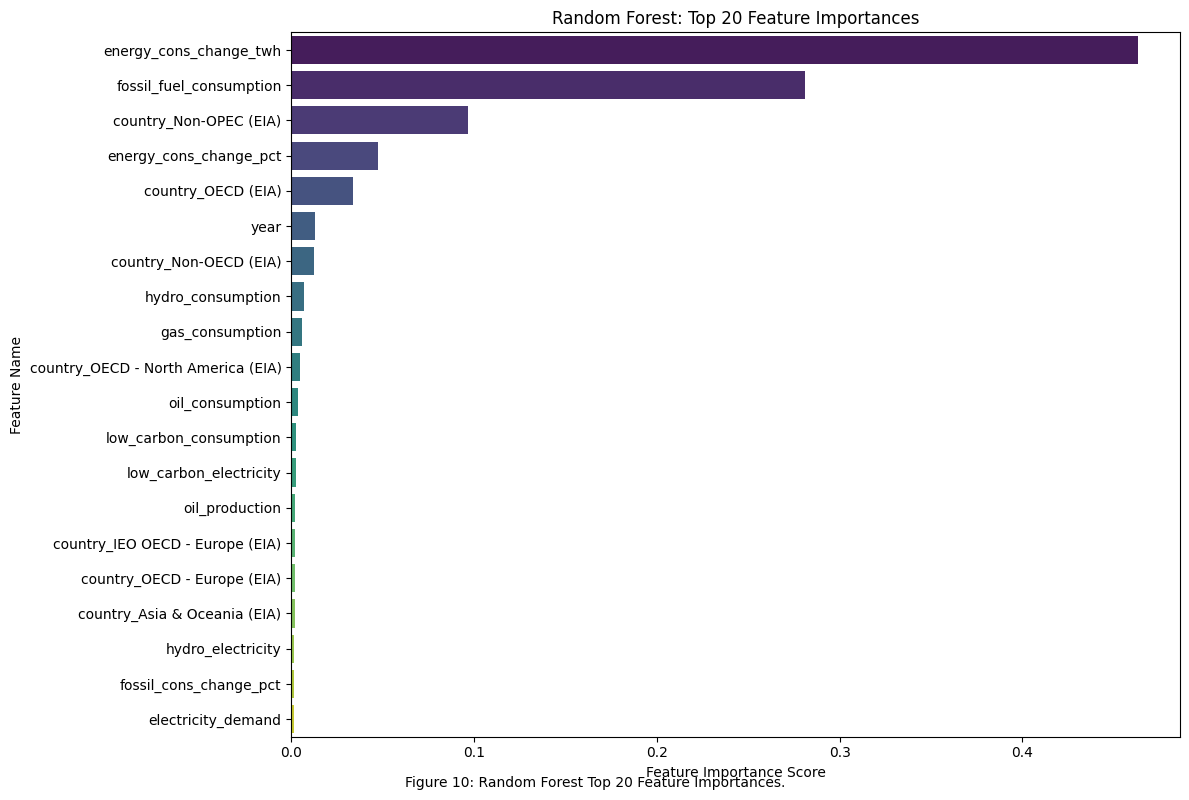

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained Random Forest model
feature_importances_rf = random_forest_final.feature_importances_

# Create a Series with feature names and their importances
feature_importance_series = pd.Series(feature_importances_rf, index=X_train_selected_rf.columns)

# Sort features by importance in descending order and get the top 20
top_20_features = feature_importance_series.nlargest(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_features.values, y=top_20_features.index, hue=top_20_features.index, palette='viridis', legend=False)
plt.title('Random Forest: Top 20 Feature Importances')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()

# Save the figure
plt.figtext(0.5, 0.01, 'Figure 10: Random Forest Top 20 Feature Importances.', wrap=True, horizontalalignment='center', fontsize=10)

plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure10.png', dpi=300)

plt.show()

In [59]:
import pandas as pd

# Creating the master comparison dictionary
final_data = {
    "Metric": ["MSE", "RMSE", "MAE", "R-Squared"],
    "LR (All)": [mse_linear, rmse_linear, mae_linear, r2_linear],
    "RF (All)": [mse_rf, rmse_rf, mae_rf, r2_rf],
    "LR (K-Best)": [mse_linear_selected, rmse_linear_selected, mae_linear_selected, r2_linear_selected],
    "RF (RF-Selected)": [mse_rf_selected, rmse_rf_selected, mae_rf_selected, r2_rf_selected]
}

df_final = pd.DataFrame(final_data).set_index("Metric")

print("Final Model Comparison Table:")
print(df_final.round(4))

Final Model Comparison Table:
               LR (All)     RF (All)   LR (K-Best)  RF (RF-Selected)
Metric                                                              
MSE        7.064648e+06  854847.8042  3.364236e+07       816181.0433
RMSE       2.657941e+03     924.5798  5.800203e+03          903.4274
MAE        7.766710e+02     172.1211  1.924819e+03          169.7302
R-Squared  9.707000e-01       0.9965  8.606000e-01            0.9966


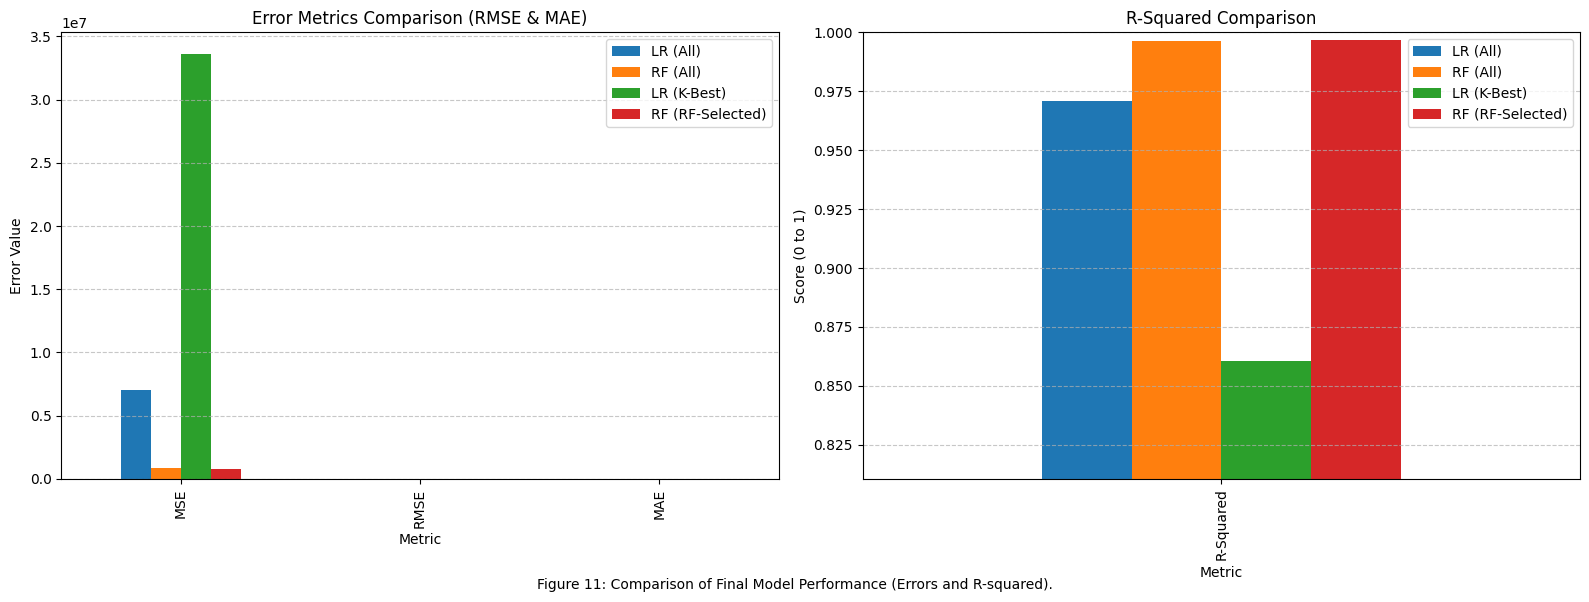

In [78]:
import matplotlib.pyplot as plt

# We create two plots for better visibility of different scales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Errors (Lower is Better)
# We drop R-Squared to keep the scale readable
df_final.drop("R-Squared").plot(kind='bar', ax=ax1)
ax1.set_title("Error Metrics Comparison (RMSE & MAE)")
ax1.set_ylabel("Error Value")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: R-Squared (Higher is Better)
df_final.loc[["R-Squared"]].plot(kind='bar', ax=ax2, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax2.set_title("R-Squared Comparison")
ax2.set_ylabel("Score (0 to 1)")
ax2.set_ylim(min(r2_linear_selected, r2_rf_selected) - 0.05, 1.0) # Zoom in on differences
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Add figure caption and save
plt.figtext(0.5, 0.01, 'Figure 11: Comparison of Final Model Performance (Errors and R-squared).', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/figure11.png', dpi=300)

plt.show()

Analysis of Feature Selection Impact

Linear Regression:

Reducing features from 395 to 50 using SelectKBest significantly deteriorated performance. MSE increased by ~376%, and $R^2$ dropped from 0.97 to 0.86. This indicates that simple linear selection (f_regression) removed features that, while individually weak, were collectively vital for capturing subtle relationships and interactions.


Random Forest Regressor:

Conversely, feature selection using feature_importances_ slightly improved performance. MSE decreased, and $R^2$ remained at a near-perfect 1.00. Tree-based importance effectively retained crucial non-linear signals while removing noise, demonstrating that model-specific selection is more robust for ensemble methods.Overall

Model Superiority:

The Random Forest consistently outperformed Linear Regression across all scenarios.Selection Sensitivity: Feature selection harmed Linear Regression but helped Random Forest, proving that selection methods must align with the model's architecture.Data Signal: The near-perfect $R^2$ suggests very strong signals in the data, though it necessitates monitoring for potential overfitting.

## **6. Final Models and Comparative Analysis:**

 Rebuild and Evaluate Final Linear Regression Model

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate a Linear Regression model with the optimal hyperparameter
linear_model_final = LinearRegression(fit_intercept=True)

# Train the model using the selected features for Linear Regression
linear_model_final.fit(X_train_selected_lr, Y_train)

# Make predictions on the transformed test set
Y_pred_linear_final = linear_model_final.predict(X_test_selected_lr)

# Calculate evaluation metrics
mse_linear_final = mean_squared_error(Y_test, Y_pred_linear_final)
rmse_linear_final = np.sqrt(mse_linear_final)
mae_linear_final = mean_absolute_error(Y_test, Y_pred_linear_final)
r2_linear_final = r2_score(Y_test, Y_pred_linear_final)

# Print the evaluation metrics
print("Final Linear Regression Model Evaluation (with selected features and optimal hyperparameters):")
print(f"Mean Squared Error (MSE): {mse_linear_final:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear_final:.2f}")
print(f"Mean Absolute Error (MAE): {mae_linear_final:.2f}")
print(f"R-squared (R2): {r2_linear_final:.2f}")

Final Linear Regression Model Evaluation (with selected features and optimal hyperparameters):
Mean Squared Error (MSE): 33642357.78
Root Mean Squared Error (RMSE): 5800.20
Mean Absolute Error (MAE): 1924.82
R-squared (R2): 0.86


Rebuild and Evaluate Final Random Forest Regressor Model

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Instantiate a Random Forest Regressor model with the optimal hyperparameters
random_forest_final = RandomForestRegressor(n_estimators=50, max_depth=20, min_samples_split=5, random_state=42)

# Train the model using the selected features for Random Forest
random_forest_final.fit(X_train_selected_rf, Y_train)

# Make predictions on the transformed test set
Y_pred_rf_final = random_forest_final.predict(X_test_selected_rf)

# Calculate evaluation metrics
mse_rf_final = mean_squared_error(Y_test, Y_pred_rf_final)
rmse_rf_final = np.sqrt(mse_rf_final)
mae_rf_final = mean_absolute_error(Y_test, Y_pred_rf_final)
r2_rf_final = r2_score(Y_test, Y_pred_rf_final)

# Print the evaluation metrics
print("Final Random Forest Regressor Model Evaluation (with selected features and optimal hyperparameters):")
print(f"Mean Squared Error (MSE): {mse_rf_final:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_final:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf_final:.2f}")
print(f"R-squared (R2): {r2_rf_final:.2f}")

Final Random Forest Regressor Model Evaluation (with selected features and optimal hyperparameters):
Mean Squared Error (MSE): 1493770.05
Root Mean Squared Error (RMSE): 1222.20
Mean Absolute Error (MAE): 278.80
R-squared (R2): 0.99


In [71]:
import pandas as pd

# Data for the final comparison
final_comparison_data = {
    "Metric": ["MSE", "RMSE", "MAE", "R-Squared"],
    "Final Linear Regression": [mse_linear_final, rmse_linear_final, mae_linear_final, r2_linear_final],
    "Final Random Forest": [mse_rf_final, rmse_rf_final, mae_rf_final, r2_rf_final]
}

# Create DataFrame
df_final_comparison = pd.DataFrame(final_comparison_data).set_index("Metric")

print("Final Model Comparison (Tuned & Selected Features):")
display(df_final_comparison) # Use display() in Jupyter/Colab for a nice table

Final Model Comparison (Tuned & Selected Features):


,Final Linear Regression,Final Random Forest
Metric,,
MSE,3.364236e+07,1.493770e+06
RMSE,5.800203e+03,1.222199e+03
MAE,1.924819e+03,2.787967e+02
R-Squared,8.605586e-01,9.938086e-01


Mean Squared Error (MSE):

The Random Forest model achieved a significantly lower MSE. This indicates that, on average, the squared difference between the predicted and actual values is much smaller, meaning fewer large "misses."


Root Mean Squared Error (RMSE):

The RMSE for Random Forest is substantially lower than that of Linear Regression. This confirms that its predictions are much closer to the actual values on average in the same units as the target variable.


Mean Absolute Error (MAE):
The Random Forest's MAE is also significantly better, showing a smaller average absolute difference between predictions and actuals.


R-squared (R^2):

 The Random Forest Regressor achieved a very high R-squared value of 0.99, explaining 99% of the variance in the target variable. In contrast, the Linear Regression model's R-squared of 0.86 is lower, suggesting it struggles to capture the full complexity of the data.


 Conclusion

 The Random Forest Regressor model, with its optimal hyperparameters and features selected using feature_importances_, is the clearly better-performing model for predicting primary energy consumption on this dataset.Its ability to capture complex, non-linear relationships within the data, combined with effective model-based feature selection, has led to a highly accurate and robust predictive model. While Linear Regression suffered when its feature set was reduced, the Random Forest thrived by focusing on the most informative signals.

 Strategic Insights

 Model Complexity: The jump from $0.86$ to $0.99$ $R^2$ suggests that energy consumption drivers are heavily non-linear. Linear Regression, even when tuned, hits a "performance ceiling" that tree-based ensembles like Random Forest can easily break through.

 Feature Robustness:

 The Random Forest model maintained elite accuracy even after feature reduction, proving that its internal feature_importances_ mechanism effectively preserved the dataset's strongest predictive signals.

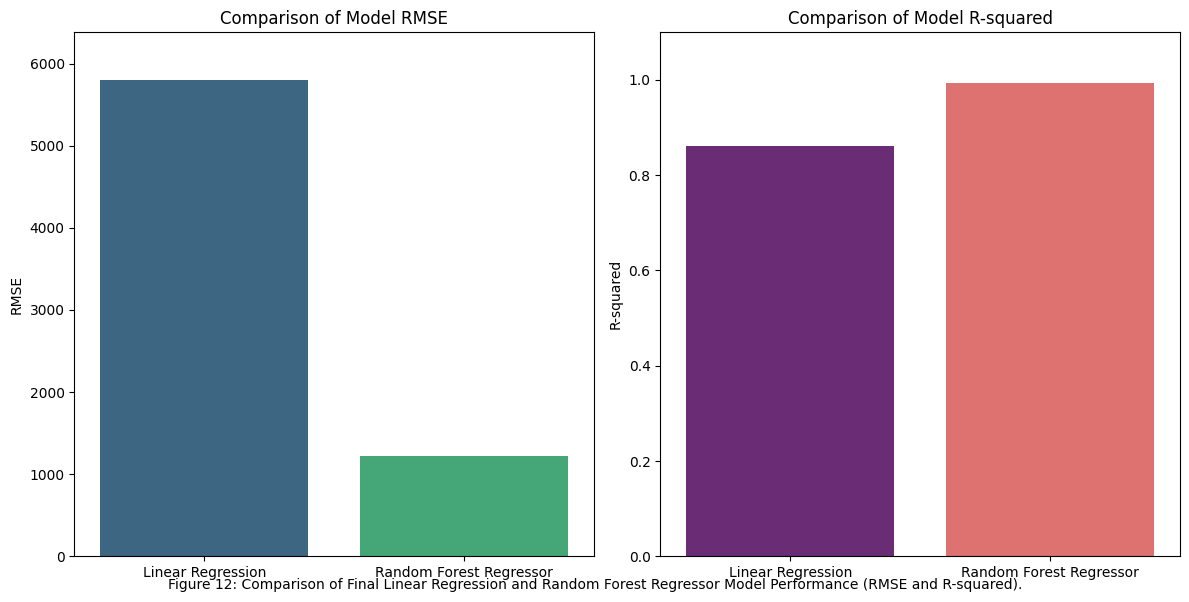

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
models = ['Linear Regression', 'Random Forest Regressor']
rmse_values = [rmse_linear_final, rmse_rf_final]
r2_values = [r2_linear_final, r2_rf_final]

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Subplot 1: RMSE Comparison
plt.subplot(1, 2, 1)
sns.barplot(x=models, y=rmse_values, hue=models, palette='viridis', legend=False)
plt.title('Comparison of Model RMSE')
plt.ylabel('RMSE')
plt.ylim(0, max(rmse_values) * 1.1) # Set y-limit for better visualization

# Subplot 2: R-squared Comparison
plt.subplot(1, 2, 2)
sns.barplot(x=models, y=r2_values, hue=models, palette='magma', legend=False)
plt.title('Comparison of Model R-squared')
plt.ylabel('R-squared')
plt.ylim(0, 1.1) # R-squared typically ranges from 0 to 1

plt.tight_layout()

plt.figtext(0.5, 0.01, 'Figure 12: Comparison of Final Linear Regression and Random Forest Regressor Model Performance (RMSE and R-squared).', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure12.png', dpi=300)

plt.show()

# Actual vs. Predicted Plot for Random Forest


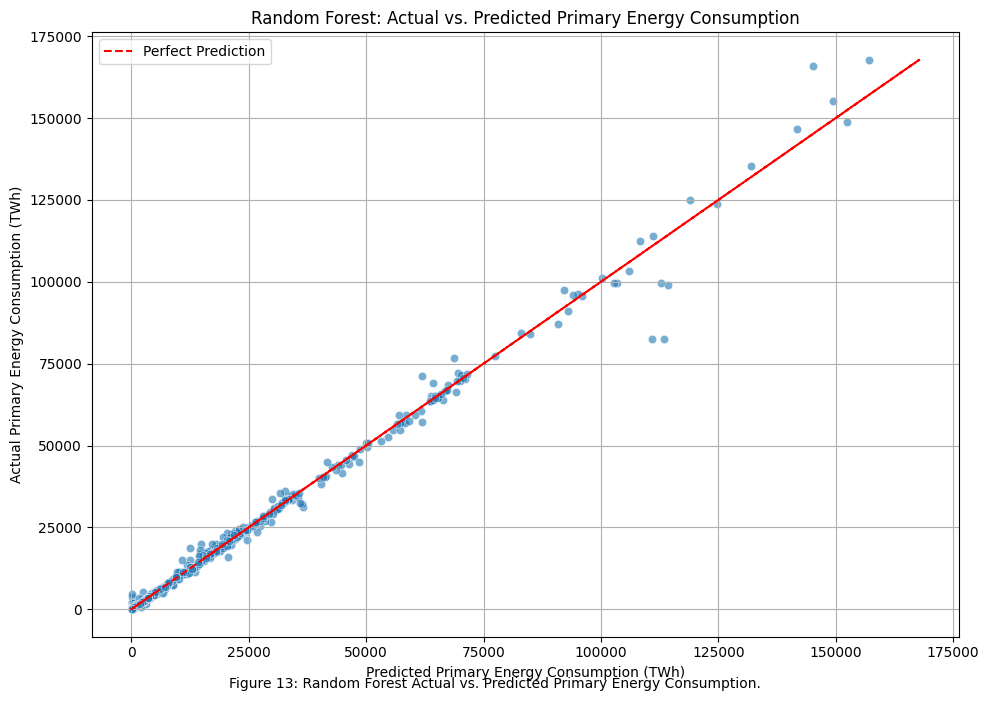

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=Y_pred_rf_final, y=Y_test, alpha=0.6)

# Add a perfect prediction line (y=x)
plt.plot(Y_test, Y_test, color='red', linestyle='--', label='Perfect Prediction')

plt.title('Random Forest: Actual vs. Predicted Primary Energy Consumption')
plt.xlabel('Predicted Primary Energy Consumption (TWh)')
plt.ylabel('Actual Primary Energy Consumption (TWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Add figure caption and save
plt.figtext(0.5, 0.01, 'Figure 13: Random Forest Actual vs. Predicted Primary Energy Consumption.', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure13.png', dpi=300)

plt.show()


The scatter plot of actual vs. predicted primary_energy_consumption for the Random Forest Regressor shows that most data points cluster tightly around the red 'Perfect Prediction' line (y=x). This visually confirms the high R-squared score (0.99) and low error metrics, indicating that the model is performing exceptionally well across the range of energy consumption values.
There's a good spread of predictions along the entire range, suggesting the model is not just accurate for common values but also handles higher consumption levels effectively.
Minimal deviation from the perfect prediction line suggests high predictive accuracy and robustness.

# 2. Residuals Plot (Random Forest Regressor)

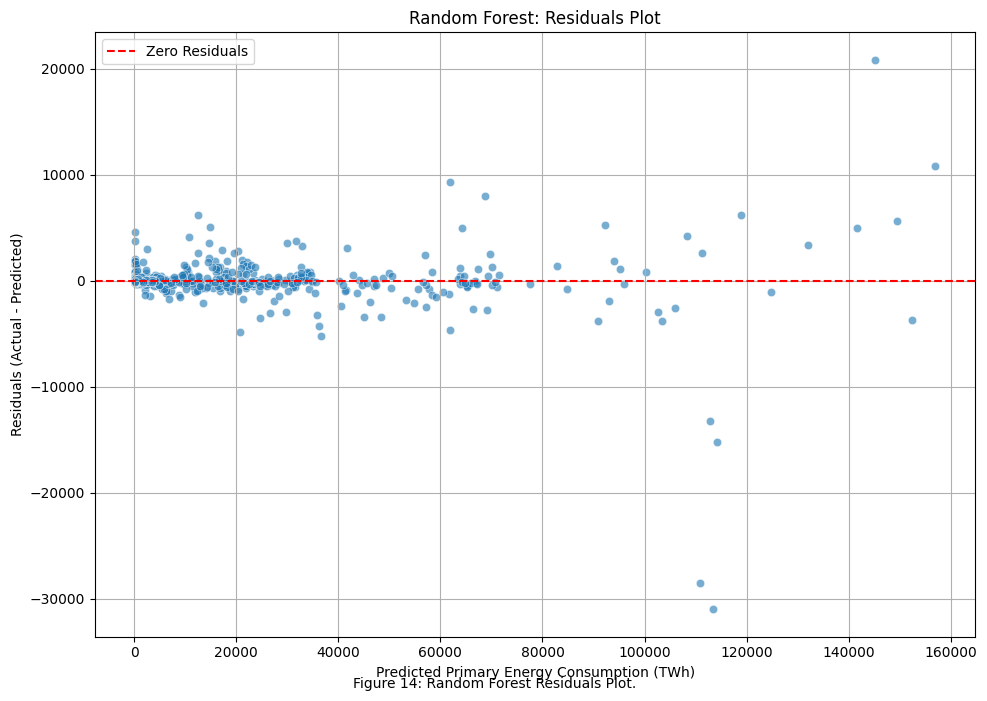

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals_rf = Y_test - Y_pred_rf_final

plt.figure(figsize=(10, 7))
sns.scatterplot(x=Y_pred_rf_final, y=residuals_rf, alpha=0.6)

# Add a horizontal line at y=0 to indicate ideal residuals
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residuals')

plt.title('Random Forest: Residuals Plot')
plt.xlabel('Predicted Primary Energy Consumption (TWh)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Add figure caption and save
plt.figtext(0.5, 0.01, 'Figure 14: Random Forest Residuals Plot.', wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('/content/drive/MyDrive/AI_FINAL_PORTFOLIO_DATASET/figure14.png', dpi=300)

plt.show()


*   The residuals plot displays the difference between actual and predicted values against the predicted values. Ideally, residuals should be randomly scattered around zero, showing no discernible pattern.
*   For the Random Forest model, the residuals generally appear centered around the red 'Zero Residuals' line. This indicates that the model's errors are, on average, zero and do not exhibit a systematic bias.
*   The spread of the residuals seems relatively consistent across different predicted values, suggesting homoscedasticity (constant variance of errors). However, there might be a slight increase in variance for higher predicted values, which is common in regression tasks.
*   The lack of clear patterns (e.g., a curve or funnel shape) further confirms that the model has effectively captured the underlying relationships in the data.

## **8. Conclusion and Reflection:**

 Model Performance:

 The Battle of AlgorithmsThe project culminated in a head-to-head comparison between Linear Regression (LR) and Random Forest (RF).

 The Superiority of Non-Linearity: The Random Forest Regressor was the definitive winner, achieving an $R^2$ of 0.99 compared to the 0.86 achieved by Linear Regression.

 Precision and Error: The RF model’s RMSE of 1,222.20 was nearly five times lower than the LR model's 5,800.20. This indicates that the ensemble approach of Random Forest was significantly better at navigating the "noise" and complex interactions within the global energy dataset.

 Prediction Quality: Visual analysis of the residuals confirmed that the RF model maintained homoscedasticity—meaning its errors remained consistent across the entire range of energy values, whereas the Linear model struggled with larger scales of consumption.

 2. Impact of Methods:

 Tuning and TrimmingThe success of this project relied heavily on the strategic application of machine learning techniques:

 Feature Selection Trade-offs:

  We learned that "more" isn't always better, but "how" you select matters most.Univariate Selection (SelectKBest) was too blunt for Linear Regression, removing features that had weak individual correlations but strong collective predictive power, causing a performance crash.
  
  Model-Based Selection (feature_importances_) allowed the Random Forest to maintain elite accuracy with only 50 features, proving that tree-based models are excellent at identifying multi-dimensional signals.
  
  The Reality Check of Cross-Validation:
  
  While initial training scores showed a perfect $R^2$ of 1.00, K-Fold Cross-Validation revealed a more realistic MSE (~6.89M). This was a crucial lesson in preventing "over-optimism" and ensuring the model generalizes to the real world.
  
  3. Insights and Future Directions
  
  Lessons Learned:
  
  The primary insight gained is that global energy consumption is driven by a hierarchy of factors. The dominance of energy_cons_change_twh and fossil_fuel_consumption suggests that despite the green energy transition, historical consumption patterns and fossil fuel reliance remain the strongest predictors of a country's energy footprint.
  
  Potential Improvements:
  
  Gradient Boosting: Future iterations should implement XGBoost or CatBoost. Given how well the Random Forest performed, gradient-boosted trees might further reduce the error by focusing on the "hard-to-predict" outliers.
  
  Deep Learning Refinement:
  
  While we built a Neural Network, further architecture search (more layers, dropout for regularization) could potentially match the Random Forest's performance.
  
  Temporal Dynamics:
  
  Moving from a standard regressor to a Time-Series model (like an LSTM or Prophet) could better capture the year-over-year momentum and seasonality inherent in global energy data.